### Расчёт рассеяния поршневой моды на поперечной стенке в бесконечном прямоугольном волноводе

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft

In [40]:
c = 5850
f = 1000000
lmbd = c / f
k = 2 * np.pi / lmbd + 0j
b = 0.04
z = np.linspace(-0.1, 0.1, 100, endpoint = False)
d_z = np.abs(z[0] - z[1])
alpha = fft.fftshift(fft.fftfreq(len(z), d_z))

In [104]:
def phi_i(z, k):
    return np.exp(1j * k * z)

def b_n(b, p):
    return b / (p * np.pi)

def K_plus(alpha, k, b, N = 100):
    res = 1.0
    for n in range(1, N + 1):
        res = res * (np.sqrt(1 - k**2 * b_n(b, n - 0.5)**2) - 1j * alpha * b_n(b, n - 0.5)) / (np.sqrt(1 - k**2 * b_n(b, n)**2) - 1j * alpha * b_n(b, n))
    return res

def gamma_n(n, k, b):
    return np.sqrt((n * np.pi / b)**2 - k**2)

def P_0(k):
    return 0.5 * (1 + (K_plus(k, k, b))**(-2))

def P_n(n, k, b):
    return (-1)**(n+1) * (1j * k) / (gamma_n(n, k, b) * K_plus(k, k, b) * K_plus(1j * gamma_n(n, k, b), k, b))

def P_n_half(n, k, b):
    return (-1)**(n+1) * (1j * k * K_plus(1j * gamma_n(n - 0.5, k, b), k, b)) / ((n - 0.5) * np.pi * gamma_n(n - 0.5, k, b) * K_plus(k, k, b))

def S(y, z, k, b, N = 100):
    res = 0.0
    for n in range(1, N + 1):
        res += P_n_half(n, k, b) * np.cos((n - 0.5) * np.pi * y / b) * np.exp(-gamma_n(n - 0.5, k, b) * np.abs(z)) + P_n(n, k, b) * np.cos(n * np.pi * y / b) * np.exp(-gamma_n(n, k, b) * np.abs(z))
    return res

def phi_t(y, z, k, b, N = 100):
    if z >= 0:
        return P_0(k) * np.exp(1j * k * z) + S(y, z, k, b, N)
    else:
        return np.exp(1j * k * z) + (1 - P_0(k)) * np.exp(- 1j * k * z) - S(y, z, k, b, N)
    
def phi(y, z, k, b, N = 100):
    return phi_t(y, z, k, b, N) - phi_i(z, k)

In [107]:
phi_vec = np.vectorize(phi_t)
phi_reflected_vec = np.vectorize(phi)
y = np.linspace(0, 2 * b, 100)
z = np.linspace(-0.1, 0.1, 100)
Z, Y = np.meshgrid(z, y)
Phi = phi_vec(Y, Z, k, b, 50)
Phi_reflected = phi_reflected_vec(Y, Z, k, b, 50)
Phi_plot = np.abs(Phi)
Phi_reflected_plot = np.abs(Phi_reflected)

In [ ]:
test = np.zeros((3, 4))
test[0, 1] = 1.0
test

array([[0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
phi_matrix = np.zeros((len(y), len(z)))
for i in len()

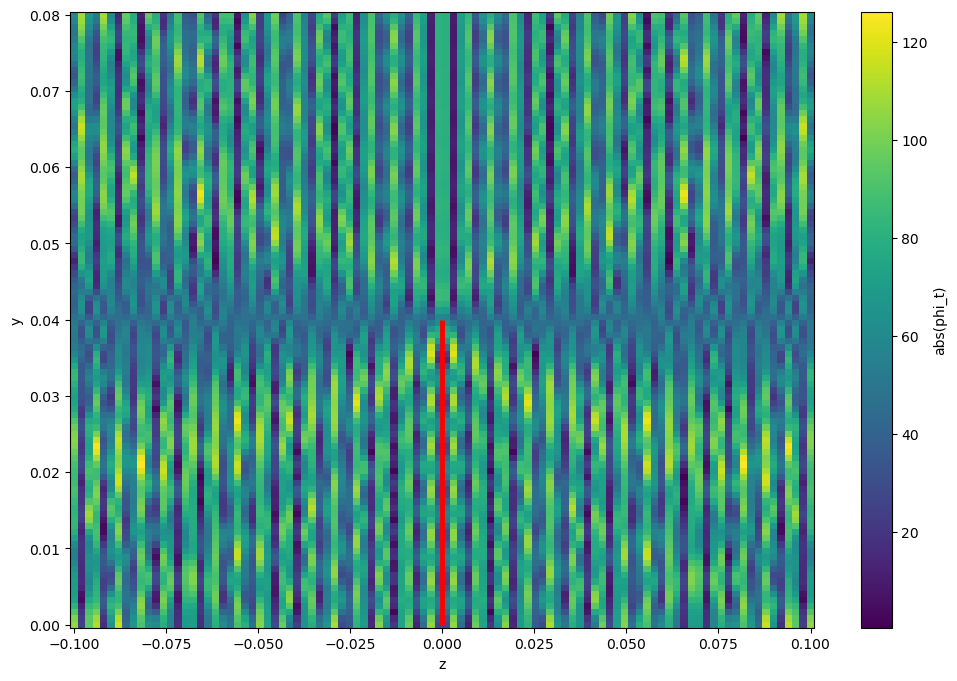

In [108]:
plt.figure(figsize = (12,8))

plt.pcolormesh(Z, Y, Phi_plot, shading='auto', cmap='viridis')

plt.xlabel('z')
plt.ylabel('y')
plt.colorbar(label='abs(phi_t)')
plt.vlines(0, 0, b, colors = 'red', linewidth = 3.5)
plt.show()

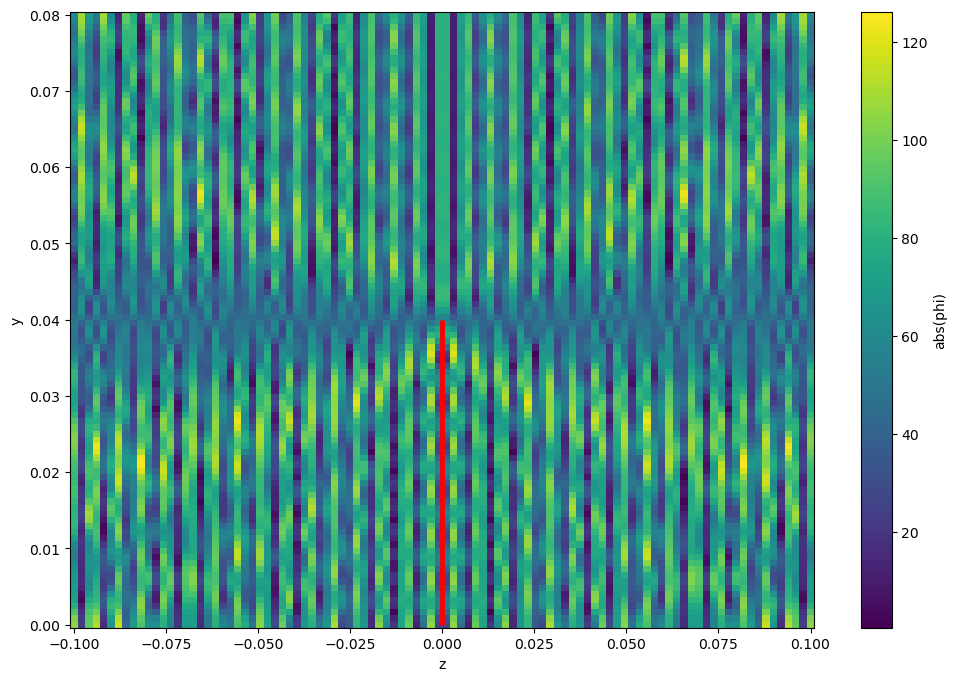

In [109]:
plt.figure(figsize = (12,8))

plt.pcolormesh(Z, Y, Phi_reflected_plot, shading='auto', cmap='viridis')

plt.xlabel('z')
plt.ylabel('y')
plt.colorbar(label='abs(phi)')
plt.vlines(0, 0, b, colors = 'red', linewidth = 3.5)
plt.show()

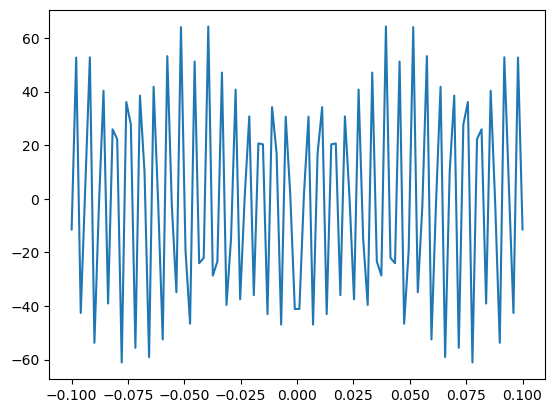

In [101]:
# def S(y, z, k, b, N = 100):
#     res = 0.0
#     for n in range(1, N + 1):
#         res += P_n_half(n, k, b) * np.cos((n - 0.5) * np.pi * y / b) * np.exp(-gamma_n(n - 0.5, k, b) * np.abs(z)) + P_n(n, k, b) * np.cos(n * np.pi * y / b) * np.exp(-gamma_n(n, k, b) * np.abs(z))
#     return res

y_plt = 0.055
z_plt = np.linspace(-0.1, 0.1, 100)

plt.plot(z_plt, S(y_plt, z_plt, k, b, 100))

In [102]:
np.argmax(z_plt)

np.int64(99)

In [103]:
z_plt[99]

np.float64(0.1)